In [100]:
import json
import pickle
from pathlib import Path
from typing import Dict, List, Optional
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
pd.set_option("display.max_columns", 50)
sns.set_theme(style="whitegrid")
BASE_ARTIFACTS_DIR = Path("artifacts")
OUTPUT_DIR = Path("notebook/outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print(f"Artifacts root: {BASE_ARTIFACTS_DIR.resolve()}")
print(f"Outputs will be saved to: {OUTPUT_DIR.resolve()}")

Artifacts root: /Users/samuel/nfl-model-platform/artifacts
Outputs will be saved to: /Users/samuel/nfl-model-platform/notebook/outputs


In [101]:
def find_artifact_dirs(base_dir: Path = BASE_ARTIFACTS_DIR) -> List[Path]:
    if not base_dir.exists():
        print(f"No artifacts directory found at {base_dir.resolve()}")
        return []
    runs: List[Path] = []
    for model_dir in base_dir.iterdir():
        if model_dir.is_dir():
            for version_dir in model_dir.iterdir():
                if version_dir.is_dir():
                    runs.append(version_dir)
    return sorted(runs)


def _metric_from_metadata(meta: Dict[str, object]) -> Dict[str, object]:
    metric_keys = [
        "holdout_rmse",
        "holdout_mae",
        "baseline_rmse",
        "best_cv_rmse",
        "beat_baseline",
    ]
    metrics = {k: meta.get(k) for k in metric_keys if k in meta}
    metrics["train_rows"] = meta.get("train_rows")
    metrics["holdout_rows"] = meta.get("holdout_rows")
    metrics["n_estimators"] = meta.get("n_estimators")
    return metrics


def load_metadata(artifact_dir: Path) -> Optional[Dict[str, object]]:
    meta_path = artifact_dir / "metadata.json"
    if not meta_path.exists():
        print(f"No metadata.json found in {artifact_dir}")
        return None
    with meta_path.open() as f:
        meta = json.load(f)
    meta["artifact_dir"] = str(artifact_dir)
    meta.setdefault("model_name", artifact_dir.parent.name)
    meta.setdefault("version", artifact_dir.name)
    return meta


def metadata_row(meta: Dict[str, object]) -> pd.DataFrame:
    metrics = _metric_from_metadata(meta)
    row = {
        "model_name": meta.get("model_name"),
        "version": meta.get("version"),
        "saved_at": meta.get("saved_at"),
        **metrics,
    }
    best_params = meta.get("best_params")
    if isinstance(best_params, dict):
        row["best_params"] = json.dumps(best_params)
    return pd.DataFrame([row])


def load_eval_results(artifact_dir: Path) -> pd.DataFrame:
    candidates = [
        artifact_dir / "evaluation.json",
        artifact_dir / "eval.json",
        artifact_dir / "metrics.json",
        artifact_dir / "metrics.csv",
    ]
    for path in candidates:
        if path.exists():
            if path.suffix == ".csv":
                df = pd.read_csv(path)
            else:
                with path.open() as f:
                    payload = json.load(f)
                if isinstance(payload, list):
                    df = pd.DataFrame(payload)
                else:
                    df = pd.DataFrame([payload])
            df["artifact_dir"] = str(artifact_dir)
            return df
    meta = load_metadata(artifact_dir)
    if meta is None:
        return pd.DataFrame()
    metrics = _metric_from_metadata(meta)
    tidy = pd.DataFrame(
        [
            {"metric": k, "value": v, "artifact_dir": str(artifact_dir)}
            for k, v in metrics.items()
            if v is not None
        ]
    )
    return tidy

In [102]:
artifact_dirs = find_artifact_dirs()
print(f"Found {len(artifact_dirs)} artifact runs:")
for idx, run in enumerate(artifact_dirs, 1):
    meta = load_metadata(run) or {}
    mode = meta.get("mode", "unknown")
    rmse = meta.get("holdout_rmse", "?")
    print(f"  {idx:02d}: {run}  [{mode}]  holdout_rmse={rmse}")

# Default: use the last (most recent) artifact for single-run cells
selected_artifact_dir = artifact_dirs[-1] if artifact_dirs else BASE_ARTIFACTS_DIR
print(f"\nSelected (default): {selected_artifact_dir}")

Found 3 artifact runs:
  01: artifacts/player_projection/v1  [full]  holdout_rmse=2.759
  02: artifacts/player_projection/v2  [athletic]  holdout_rmse=11.1505
  03: artifacts/player_projection/v3  [full]  holdout_rmse=2.5194

Selected (default): artifacts/player_projection/v3


In [103]:
eval_frames: List[pd.DataFrame] = []
for run in artifact_dirs:
    df = load_eval_results(run)
    if not df.empty:
        df["model_name"] = run.parent.name
        df["version"] = run.name
        eval_frames.append(df)
eval_df = pd.concat(eval_frames, ignore_index=True) if eval_frames else pd.DataFrame()
display(eval_df.head())
print(f"Eval rows: {len(eval_df)}")

,metric,value,artifact_dir,model_name,version
0,holdout_rmse,2.759,artifacts/player_projection/v1,player_projection,v1
1,holdout_mae,1.0674,artifacts/player_projection/v1,player_projection,v1
2,baseline_rmse,14.916,artifacts/player_projection/v1,player_projection,v1
3,best_cv_rmse,5.5496,artifacts/player_projection/v1,player_projection,v1
4,beat_baseline,True,artifacts/player_projection/v1,player_projection,v1


Eval rows: 24


In [104]:
# ── Cross-version metrics comparison table ───────────────────────────────────
METRIC_COLS = ["holdout_rmse", "holdout_mae", "best_cv_rmse", "baseline_rmse",
               "beat_baseline", "n_estimators", "train_rows", "holdout_rows"]

rows = []
for run in artifact_dirs:
    meta = load_metadata(run)
    if not meta:
        continue
    row = {
        "version":  meta.get("version", run.name),
        "mode":     meta.get("mode", "full"),
        "excluded": ", ".join(meta.get("excluded_features", [])) or "—",
    }
    for k in METRIC_COLS:
        row[k] = meta.get(k)
    rows.append(row)

compare_df = pd.DataFrame(rows).set_index("version")
display(compare_df[["mode", "holdout_rmse", "holdout_mae", "best_cv_rmse",
                     "baseline_rmse", "beat_baseline", "n_estimators"]])

# Gap analysis
if len(compare_df) >= 2:
    full_rmse = compare_df.loc[compare_df["mode"] == "full", "holdout_rmse"].min()
    ath_rmse  = compare_df.loc[compare_df["mode"] == "athletic", "holdout_rmse"].min()
    if pd.notna(full_rmse) and pd.notna(ath_rmse):
        print(f"\nDraft-value feature contribution: "
              f"{ath_rmse:.4f} (athletic) − {full_rmse:.4f} (full) = "
              f"+{ath_rmse - full_rmse:.4f} RMSE when removed")

,mode,holdout_rmse,holdout_mae,best_cv_rmse,baseline_rmse,beat_baseline,n_estimators
version,,,,,,,
v1,full,2.7590,1.0674,5.5496,14.916,True,964
v2,athletic,11.1505,8.7689,19.3426,14.916,True,320
v3,full,2.5194,0.8801,5.2492,14.916,True,1999



Draft-value feature contribution: 11.1505 (athletic) − 2.5194 (full) = +8.6311 RMSE when removed


Columns after reset: ['player_name', 'draft_year', 'forty_yard', 'vertical_in', 'bench_reps', 'broad_jump_in', 'three_cone', 'shuttle', 'height_in', 'weight_lbs', 'speed_score', 'agility_score', 'burst_score', 'strength_score', 'size_score', 'draft_value_score', 'draft_value_percentile', 'age', 'pos_QB', 'pos_SKILL', 'pos_OL', 'pos_DL', 'pos_LB', 'pos_DB', 'pos_SPEC', 'missing_forty_yard', 'missing_vertical_in', 'missing_bench_reps', 'missing_broad_jump_in', 'missing_three_cone', 'missing_shuttle', 'round_x_draft_value', '_car_av', 'artifact_dir']
val            _car_av
count  1155.000000
mean     19.077922
std      19.869090
min       0.000000
25%       4.000000
50%      12.000000
75%      30.000000
max     115.000000
holdout        _car_av
count      0.0
mean       NaN
std        NaN
min        NaN
25%        NaN
50%        NaN
75%        NaN
max        NaN


/var/folders/t8/_2vv47_s12d49vpmvrkng3c80000gn/T/ipykernel_98009/3964485488.py:33: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(data=hold_df, x=target_col, label="holdout", fill=True)


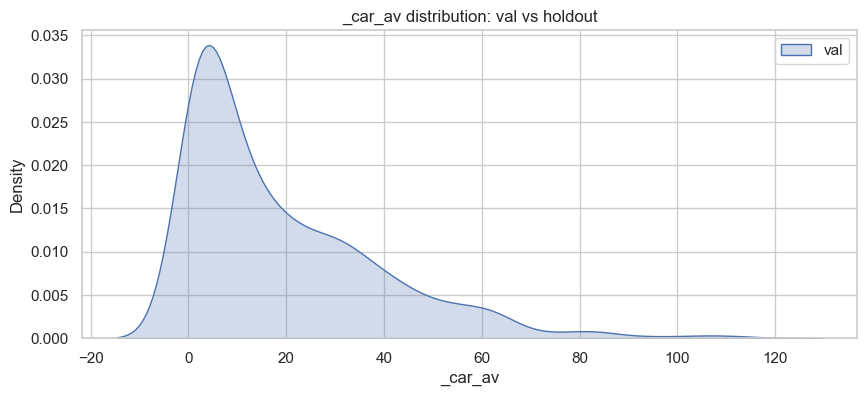

In [105]:
def load_feature_data(artifact_dir: Path) -> Optional[pd.DataFrame]:
    parquet_path = artifact_dir / "train_features.parquet"
    if parquet_path.exists():
        df = pd.read_parquet(parquet_path)
        df["artifact_dir"] = str(artifact_dir)
        return df
    print(f"No train_features.parquet found in {artifact_dir}")
    return None


features_df = load_feature_data(selected_artifact_dir)

# val vs holdout
features_df = load_feature_data(selected_artifact_dir)
if features_df is not None:
    features_df = features_df.reset_index()  # brings draft_year/player_name out of the index
    target_col = "_car_av"
    year_col = "draft_year"
    print("Columns after reset:", features_df.columns.tolist())
else:
    target_col = "_car_av"
    year_col = "draft_year"
if features_df is not None and target_col in features_df.columns and year_col in features_df.columns:
    val_years = [2015, 2016, 2017, 2018, 2019, 2020]
    holdout_years = [2021, 2022]
    def subset(years):
        return features_df[features_df[year_col].isin(years)]
    val_df, hold_df = subset(val_years), subset(holdout_years)
    for name, df in [("val", val_df), ("holdout", hold_df)]:
        print(name, df[[target_col]].describe())
    plt.figure(figsize=(10,4))
    sns.kdeplot(data=val_df, x=target_col, label="val", fill=True)
    sns.kdeplot(data=hold_df, x=target_col, label="holdout", fill=True)
    plt.title(f"{target_col} distribution: val vs holdout")
    plt.legend()
    plt.show()
else:
    missing = [c for c in [target_col, year_col] if c not in (features_df.columns if features_df is not None else [])]
    print("Missing columns:", missing)

# print(features_df.columns.tolist())
# print(features_df.head())


,train_end,val_start,val_end
0,2014,2015,2016
1,2016,2017,2018
2,2018,2019,2020


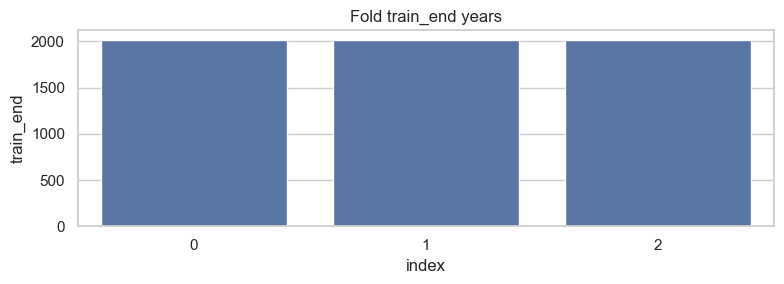

In [97]:
selected_meta = load_metadata(selected_artifact_dir)
if selected_meta and "folds" in selected_meta:
    folds_df = pd.DataFrame(selected_meta["folds"])
    display(folds_df)
    plt.figure(figsize=(8, 3))
    sns.barplot(data=folds_df.reset_index(), x="index", y="train_end")
    plt.title("Fold train_end years")
    plt.tight_layout()
    plt.show()
else:
    print("No fold info found in metadata.")

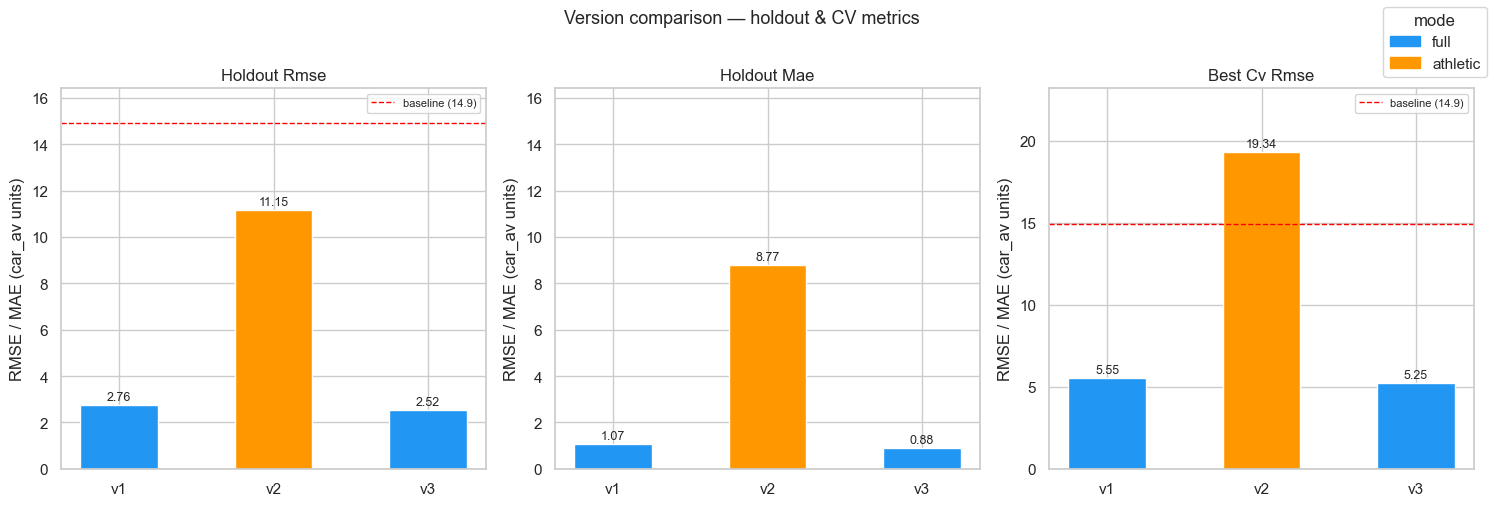

In [107]:
# ── Metrics bar chart: all versions side-by-side ─────────────────────────────
if not compare_df.empty:
    plot_df = compare_df.reset_index()[["version", "mode", "holdout_rmse", "holdout_mae", "best_cv_rmse", "baseline_rmse"]]
    melted  = plot_df.melt(id_vars=["version", "mode"], var_name="metric", value_name="value")

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    for ax, metric in zip(axes, ["holdout_rmse", "holdout_mae", "best_cv_rmse"]):
        sub = melted[melted["metric"] == metric].copy()
        palette = {"full": "#2196F3", "athletic": "#FF9800", "unknown": "#9E9E9E"}
        bars = ax.bar(sub["version"], sub["value"],
                      color=[palette.get(m, "#9E9E9E") for m in sub["mode"]], width=0.5)
        # baseline reference line
        baseline = compare_df["baseline_rmse"].iloc[0]
        if metric in ("holdout_rmse", "best_cv_rmse"):
            ax.axhline(baseline, color="red", linestyle="--", linewidth=1, label=f"baseline ({baseline:.1f})")
            ax.legend(fontsize=8)
        for bar, val in zip(bars, sub["value"]):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                    f"{val:.2f}", ha="center", va="bottom", fontsize=9)
        ax.set_title(metric.replace("_", " ").title())
        ax.set_ylabel("RMSE / MAE (car_av units)")
        ax.set_ylim(0, max(sub["value"].max() * 1.2, baseline * 1.1))

    # Legend for mode colours
    from matplotlib.patches import Patch
    legend_handles = [Patch(color="#2196F3", label="full"), Patch(color="#FF9800", label="athletic")]
    fig.legend(handles=legend_handles, loc="upper right", title="mode")
    fig.suptitle("Version comparison — holdout & CV metrics", fontsize=13, y=1.01)
    plt.tight_layout()
    plt.show()


Loaded model from artifacts/player_projection/v1/model.pkl
Loaded model from artifacts/player_projection/v2/model.pkl
Loaded model from artifacts/player_projection/v3/model.pkl


 98%|===================| 490/500 [00:40<00:00]        

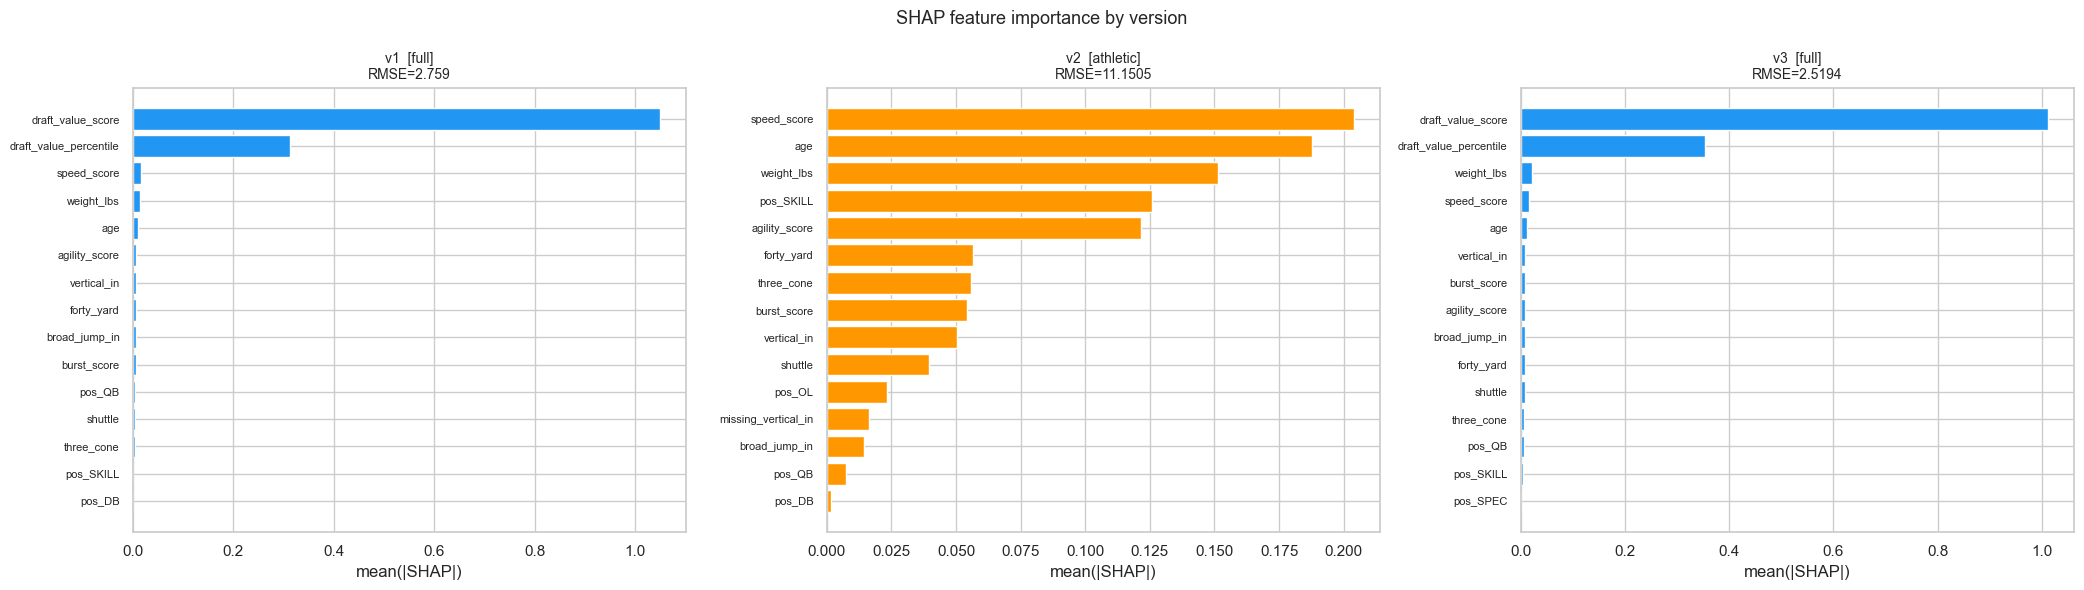

Saved → notebook/outputs/shap_comparison.png


In [108]:
# ── SHAP feature importance — one panel per version ──────────────────────────
import shap

fig, axes = plt.subplots(1, len(artifact_dirs), figsize=(7 * len(artifact_dirs), 6))
if len(artifact_dirs) == 1:
    axes = [axes]

for ax, run in zip(axes, artifact_dirs):
    meta  = load_metadata(run) or {}
    model = load_model(run)
    feat_df = load_feature_data(run)
    version = meta.get("version", run.name)
    mode    = meta.get("mode", "?")

    if model is None or feat_df is None:
        ax.set_title(f"{version} — no model/features")
        continue

    feature_cols = (meta.get("feature_names")
                    or (list(model.feature_names_in_) if hasattr(model, "feature_names_in_") else []))
    feature_cols = [c for c in feature_cols if c in feat_df.columns]

    sample = (feat_df[feature_cols]
              .sample(n=min(500, len(feat_df)), random_state=42)
              .astype(float)
              .reset_index(drop=True))
    try:
        explainer = shap.Explainer(model, sample)
        sv = explainer(sample)
        mean_abs = np.abs(sv.values).mean(axis=0)
    except Exception:
        # fallback: native XGBoost pred_contribs
        import xgboost as xgb
        dm = xgb.DMatrix(sample, feature_names=feature_cols)
        contribs = model.get_booster().predict(dm, pred_contribs=True)
        mean_abs = np.abs(contribs[:, :-1]).mean(axis=0)

    fi = (pd.DataFrame({"feature": feature_cols, "mean_|SHAP|": mean_abs})
          .sort_values("mean_|SHAP|", ascending=True)
          .tail(15))

    ax.barh(fi["feature"], fi["mean_|SHAP|"], color="#2196F3" if mode == "full" else "#FF9800")
    ax.set_title(f"{version}  [{mode}]\nRMSE={meta.get('holdout_rmse','?')}", fontsize=10)
    ax.set_xlabel("mean(|SHAP|)")
    ax.tick_params(axis="y", labelsize=8)

plt.suptitle("SHAP feature importance by version", fontsize=13)
plt.tight_layout()
plt.show()
print(f"Saved → {OUTPUT_DIR / 'shap_comparison.png'}")

## Version interpretation guide

| Version | Mode | What it tells you |
|---|---|---|
| **v1** | full (old, no log1p) | Baseline — draft consensus dominates, RMSE inflated by elite outliers |
| **v2** | athletic | Pure combine signal, no draft position. Higher RMSE expected — shows how much teams' own evaluation contributes |
| **v3** | full + log1p | Best raw accuracy. log1p rebalances loss so busts/starters matter equally |

**Reading the gap:**  
`v2 RMSE − v3 RMSE` ≈ the marginal value of draft-position features.  
If this gap is large, the model's accuracy is mostly "trusting the draft order."  
If small, combine/athletic data captures comparable signal independently.

**When to use each:**  
- Use **v3** for post-draft accuracy (best predictions when pick is known)  
- Use **v2** to find players the draft mis-valued (athletic signal independent of consensus)